# Notebook 05 — Model Definition & Training (Main Model)

**Purpose:** define the L-TAE-based multi-task regression model and train
it on the prepared data.

**Architectural fixes from earlier prototypes:**
1. **Sinusoidal positional encoding** is now part of L-TAE - the original
   paper includes it and it is critical for multi-year sequences.
2. **Padding mask is passed through** so attention ignores padded positions.
3. **RPS weights are unified** between the analytical target and any post-hoc
   computation - both read from `config.RPS_WEIGHTS`.
4. **Direct RPS head** is the primary regression output.

**Inputs:** processed tensors from Notebook 04
**Outputs:** trained model, training history, test-set predictions


In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive", force_remount=False)


Mounted at /content/drive


In [2]:
# Load shared configuration.
# config.py must sit at /content/drive/MyDrive/thesis/config.py
import sys, importlib
sys.path.insert(0, "/content/drive/MyDrive/thesis")
import config
importlib.reload(config)

config.ensure_dirs()
config.set_seed()
config.print_summary()


Version:       _10m
GEE project:   bar-project-457815
Scale:         10 m   CRS: EPSG:32636
Period:        2017-2025  (107 months)
S2 collection: projects/bar-project-457815/assets/s2_monthly_image_collection_10m
Features:      27 model inputs (28 total available)
RPS weights:   {'recurrence': 0.25, 'severity': 0.25, 'persistence': 0.25, 'recovery': 0.25}
Seed:          42


In [3]:
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (f1_score, roc_auc_score,
                             classification_report,
                             precision_recall_curve)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


Device: cuda


## 1. Load processed data

In [4]:
X        = np.load(config.FILES["X_scaled"])
y        = np.load(config.FILES["y_burned"])
mask     = np.load(config.FILES["X_scaled"].replace(".npy", "_mask.npy"))
targets  = dict(np.load(config.FILES["targets_aux"]))

with open(config.FILES["splits"]) as f:
    splits = json.load(f)
with open(config.FILES["feature_names"]) as f:
    feature_names = json.load(f)

idx_train = np.array(splits["train"])
idx_val   = np.array(splits["val"])
idx_test  = np.array(splits["test"])

N, T, C = X.shape
print(f"X={X.shape}  features={C}  T={T}")
print(f"Train/Val/Test: {len(idx_train)}/{len(idx_val)}/{len(idx_test)}")


X=(9667, 107, 26)  features=26  T=107
Train/Val/Test: 6766/1450/1451


## 2. Model definition

### Positional encoding

Sinusoidal positional encoding adds calendar-position information to each
time step. `tau` controls the frequency range; larger `tau` spreads the
encoding over longer sequences. The original paper used `tau=1000` for
sequences of ~300 days; we use `tau=10000` for ~3000-day sequences.


In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len, tau):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() *
            (-math.log(tau) / d_model)
        )
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[: x.size(1)].unsqueeze(0)


### L-TAE block

Channel grouping splits the input feature dimension across heads. Each head
holds its own learned master query and operates on its own slice of channels.
The padding mask blocks attention from attending to padded positions.


In [6]:
class LTAE(nn.Module):
    def __init__(self, d_model, n_head, d_k, max_len, tau, dropout=0.1):
        super().__init__()
        assert d_model % n_head == 0, "d_model must be divisible by n_head"
        self.n_head  = n_head
        self.d_model = d_model
        self.d_k     = d_k
        self.d_head  = d_model // n_head

        self.pos_enc      = PositionalEncoding(d_model, max_len, tau)
        self.master_query = nn.Parameter(torch.randn(n_head, d_k) * 0.1)
        self.key_proj     = nn.Linear(self.d_head, d_k, bias=False)
        self.dropout      = nn.Dropout(dropout)
        self.layer_norm   = nn.LayerNorm(d_model)

        self.attention_weights = None

    def forward(self, x, mask=None):
        B, T, D = x.shape
        H = self.n_head

        x = self.pos_enc(x)
        x_heads = x.view(B, T, H, self.d_head)

        keys = self.key_proj(x_heads)
        q    = self.master_query.unsqueeze(0).unsqueeze(0)

        scores = (keys * q).sum(dim=-1) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(
                (~mask).unsqueeze(-1).expand_as(scores),
                float("-inf"),
            )

        attn = F.softmax(scores, dim=1)
        attn = self.dropout(attn)
        self.attention_weights = attn.detach()

        context = (attn.unsqueeze(-1) * x_heads).sum(dim=1)
        context = context.view(B, D)
        return self.layer_norm(context)


### Full multi-task model

In [7]:
class FireRecoveryModel(nn.Module):
    def __init__(self, n_features, d_model, n_head, d_k,
                 max_len, tau, dropout=0.1):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(n_features, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.ltae = LTAE(d_model=d_model, n_head=n_head, d_k=d_k,
                         max_len=max_len, tau=tau, dropout=dropout)

        # Per-month burned head sees the local embedding plus the global context
        self.head_burned = nn.Sequential(
            nn.Linear(d_model * 2, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

        def regression_head():
            return nn.Sequential(
                nn.Linear(d_model, 64), nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(64, 1), nn.Sigmoid(),
            )

        self.head_severity    = regression_head()
        self.head_persistence = regression_head()
        self.head_recovery    = regression_head()

        self.head_rps = nn.Sequential(
            nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32), nn.GELU(),
            nn.Linear(32, 1), nn.Sigmoid(),
        )

    def forward(self, x, mask=None):
        B, T, C = x.shape
        h       = self.input_proj(x)
        context = self.ltae(h, mask)

        context_exp   = context.unsqueeze(1).expand(B, T, -1)
        burned_input  = torch.cat([h, context_exp], dim=-1)
        burned_logits = self.head_burned(burned_input).squeeze(-1)

        return {
            "burned_logits": burned_logits,
            "severity":      self.head_severity(context).squeeze(-1),
            "persistence":   self.head_persistence(context).squeeze(-1),
            "recovery":      self.head_recovery(context).squeeze(-1),
            "rps":           self.head_rps(context).squeeze(-1),
        }


### Loss

In [8]:
class FocalLoss(nn.Module):
    """Focal loss with mask support for padded positions."""

    def __init__(self, alpha, gamma):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets, mask=None):
        bce  = F.binary_cross_entropy_with_logits(
            logits, targets, reduction="none")
        prob = torch.sigmoid(logits)
        p_t  = prob * targets + (1 - prob) * (1 - targets)
        loss = bce * ((1 - p_t) ** self.gamma)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss = alpha_t * loss

        if mask is not None:
            loss = loss * mask.float()
            return loss.sum() / mask.float().sum().clamp(min=1)
        return loss.mean()


class MultiTaskLoss(nn.Module):
    def __init__(self, alpha, gamma, lambda_aux, lambda_rps):
        super().__init__()
        self.focal      = FocalLoss(alpha=alpha, gamma=gamma)
        self.mse        = nn.MSELoss()
        self.lambda_aux = lambda_aux
        self.lambda_rps = lambda_rps

    def forward(self, outputs, targets, mask):
        loss_burned = self.focal(
            outputs["burned_logits"], targets["burned"], mask)
        loss_sev = self.mse(outputs["severity"],    targets["severity"])
        loss_per = self.mse(outputs["persistence"], targets["persistence"])
        loss_rec = self.mse(outputs["recovery"],    targets["recovery"])
        loss_aux = (loss_sev + loss_per + loss_rec) / 3
        loss_rps = self.mse(outputs["rps"], targets["rps"])

        total = (loss_burned +
                 self.lambda_aux * loss_aux +
                 self.lambda_rps * loss_rps)

        return {
            "total":     total,
            "burned":    loss_burned,
            "auxiliary": loss_aux,
            "rps":       loss_rps,
        }


## 3. Build data loaders

In [9]:
def make_loader(indices, batch_size, shuffle):
    ds = TensorDataset(
        torch.tensor(X[indices]),
        torch.tensor(y[indices]),
        torch.tensor(mask[indices]),
        torch.tensor(targets["severity"][indices]),
        torch.tensor(targets["persistence"][indices]),
        torch.tensor(targets["recovery"][indices]),
        torch.tensor(targets["rps"][indices]),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      drop_last=False)


train_loader = make_loader(idx_train, config.TRAINING["batch_size"], True)
val_loader   = make_loader(idx_val,   config.TRAINING["batch_size"], False)
test_loader  = make_loader(idx_test,  config.TRAINING["batch_size"], False)


## 4. Instantiate model, loss, optimiser

In [10]:
model = FireRecoveryModel(
    n_features=C,
    d_model=config.MODEL["d_model"],
    n_head=config.MODEL["n_head"],
    d_k=config.MODEL["d_k"],
    max_len=T,
    tau=config.MODEL["positional_tau"],
    dropout=config.MODEL["dropout"],
).to(DEVICE)

criterion = MultiTaskLoss(
    alpha=config.LOSS["focal_alpha"],
    gamma=config.LOSS["focal_gamma"],
    lambda_aux=config.LOSS["lambda_aux"],
    lambda_rps=config.LOSS["lambda_rps"],
)
optimizer = optim.AdamW(
    model.parameters(),
    lr=config.TRAINING["lr"],
    weight_decay=config.TRAINING["weight_decay"],
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=config.TRAINING["epochs"])

n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")


Total parameters: 56,965


## 5. Training loop

In [11]:
def run_epoch(loader, train):
    model.train(train)
    sums = {"total": 0, "burned": 0, "auxiliary": 0, "rps": 0, "n": 0}
    probs_all, labels_all, mask_all = [], [], []

    for batch in loader:
        X_b, y_b, m_b, sev_b, per_b, rec_b, rps_b = (
            b.to(DEVICE) for b in batch)
        tgt = {"burned": y_b, "severity": sev_b,
               "persistence": per_b, "recovery": rec_b, "rps": rps_b}

        if train:
            optimizer.zero_grad()
        outputs = model(X_b, mask=m_b)
        losses  = criterion(outputs, tgt, m_b)

        if train:
            losses["total"].backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), config.TRAINING["grad_clip"])
            optimizer.step()

        bs = X_b.size(0)
        for k in ["total", "burned", "auxiliary", "rps"]:
            sums[k] += losses[k].item() * bs
        sums["n"] += bs

        probs_all.append(
            torch.sigmoid(outputs["burned_logits"]).detach().cpu().numpy())
        labels_all.append(y_b.cpu().numpy())
        mask_all.append(m_b.cpu().numpy())

    metrics = {k: sums[k] / sums["n"]
               for k in ["total", "burned", "auxiliary", "rps"]}
    probs   = np.concatenate(probs_all).reshape(-1)
    labels  = np.concatenate(labels_all).reshape(-1)
    msk     = np.concatenate(mask_all).reshape(-1).astype(bool)
    try:
        metrics["auc"] = roc_auc_score(labels[msk], probs[msk])
    except ValueError:
        metrics["auc"] = float("nan")
    return metrics


history = {"train": [], "val": []}
best_val_auc = -1.0
best_state   = None

for epoch in range(1, config.TRAINING["epochs"] + 1):
    train_m = run_epoch(train_loader, train=True)
    val_m   = run_epoch(val_loader,   train=False)
    scheduler.step()

    history["train"].append(train_m)
    history["val"].append(val_m)

    if val_m["auc"] > best_val_auc:
        best_val_auc = val_m["auc"]
        best_state   = {k: v.cpu().clone()
                        for k, v in model.state_dict().items()}

    if epoch == 1 or epoch % 5 == 0:
        print(f"epoch {epoch:3d}  "
              f"train_total={train_m['total']:.4f}  "
              f"val_total={val_m['total']:.4f}  "
              f"val_auc={val_m['auc']:.4f}")

print(f"\nBest val AUC: {best_val_auc:.4f}")


epoch   1  train_total=0.0592  val_total=0.0450  val_auc=0.7832
epoch   5  train_total=0.0330  val_total=0.0362  val_auc=0.8652
epoch  10  train_total=0.0296  val_total=0.0326  val_auc=0.8870
epoch  15  train_total=0.0277  val_total=0.0301  val_auc=0.8992
epoch  20  train_total=0.0261  val_total=0.0292  val_auc=0.9092
epoch  25  train_total=0.0243  val_total=0.0292  val_auc=0.9151
epoch  30  train_total=0.0231  val_total=0.0284  val_auc=0.9179
epoch  35  train_total=0.0223  val_total=0.0286  val_auc=0.9206
epoch  40  train_total=0.0215  val_total=0.0279  val_auc=0.9225
epoch  45  train_total=0.0211  val_total=0.0276  val_auc=0.9233
epoch  50  train_total=0.0211  val_total=0.0277  val_auc=0.9233

Best val AUC: 0.9233


## 6. Threshold tuning on the validation set

In [12]:
model.load_state_dict(best_state)
model.eval()

val_probs, val_labels, val_mask = [], [], []
with torch.no_grad():
    for batch in val_loader:
        X_b, y_b, m_b, *_ = (b.to(DEVICE) for b in batch)
        out = model(X_b, mask=m_b)
        val_probs.append(torch.sigmoid(out["burned_logits"]).cpu().numpy())
        val_labels.append(y_b.cpu().numpy())
        val_mask.append(m_b.cpu().numpy())

val_probs  = np.concatenate(val_probs).reshape(-1)
val_labels = np.concatenate(val_labels).reshape(-1)
val_mask   = np.concatenate(val_mask).reshape(-1).astype(bool)

thresholds = np.linspace(0.01, 0.99, 200)
f1s = [f1_score(val_labels[val_mask],
                (val_probs[val_mask] >= t).astype(int),
                zero_division=0) for t in thresholds]
best_thr = thresholds[int(np.argmax(f1s))]
print(f"Best threshold: {best_thr:.3f}   F1: {max(f1s):.3f}")


Best threshold: 0.261   F1: 0.394


## 7. Test-set evaluation

In [13]:
test_probs, test_labels, test_mask, test_rps = [], [], [], []

with torch.no_grad():
    for batch in test_loader:
        X_b, y_b, m_b, *_ = (b.to(DEVICE) for b in batch)
        out = model(X_b, mask=m_b)
        test_probs.append(torch.sigmoid(out["burned_logits"]).cpu().numpy())
        test_labels.append(y_b.cpu().numpy())
        test_mask.append(m_b.cpu().numpy())
        test_rps.append(out["rps"].cpu().numpy())

test_probs  = np.concatenate(test_probs).reshape(-1)
test_labels = np.concatenate(test_labels).reshape(-1)
test_mask   = np.concatenate(test_mask).reshape(-1).astype(bool)
test_rps    = np.concatenate(test_rps)

preds = (test_probs[test_mask] >= best_thr).astype(int)
print(classification_report(
    test_labels[test_mask], preds,
    target_names=["not_burned", "burned"], zero_division=0))
print(f"AUC: {roc_auc_score(test_labels[test_mask], test_probs[test_mask]):.4f}")


              precision    recall  f1-score   support

  not_burned       0.99      1.00      1.00    147803
      burned       0.45      0.33      0.38      1180

    accuracy                           0.99    148983
   macro avg       0.72      0.66      0.69    148983
weighted avg       0.99      0.99      0.99    148983

AUC: 0.9221


## 8. Diagnostic plots

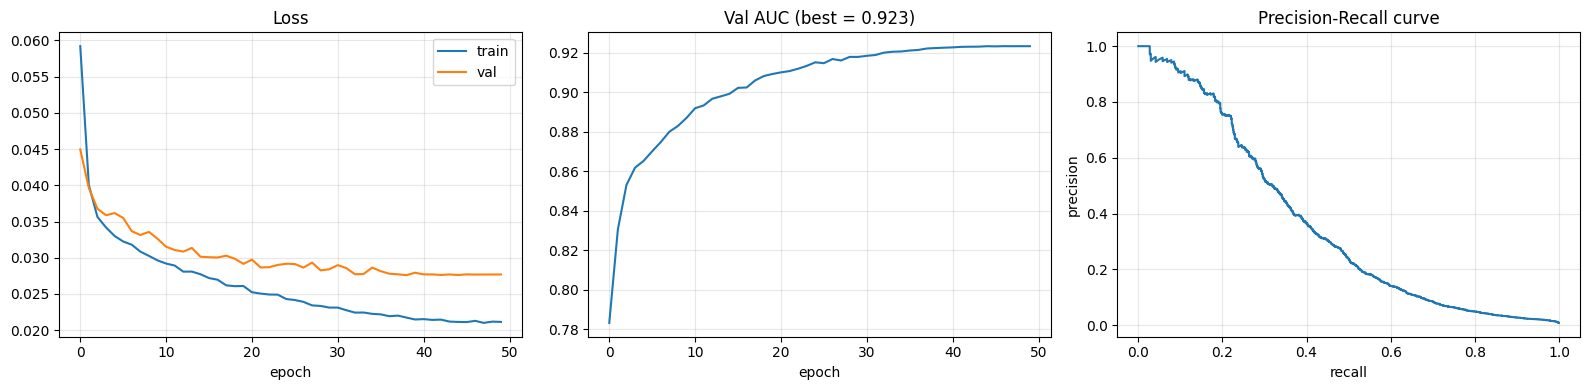

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

train_loss = [h["total"] for h in history["train"]]
val_loss   = [h["total"] for h in history["val"]]
val_auc    = [h["auc"]   for h in history["val"]]

axes[0].plot(train_loss, label="train")
axes[0].plot(val_loss,   label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(val_auc)
axes[1].set_title(f"Val AUC (best = {best_val_auc:.3f})")
axes[1].set_xlabel("epoch")
axes[1].grid(True, alpha=0.3)

precision, recall, _ = precision_recall_curve(
    val_labels[val_mask], val_probs[val_mask])
axes[2].plot(recall, precision)
axes[2].set_xlabel("recall")
axes[2].set_ylabel("precision")
axes[2].set_title("Precision-Recall curve")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{config.PATHS['outputs_fig']}/training_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()


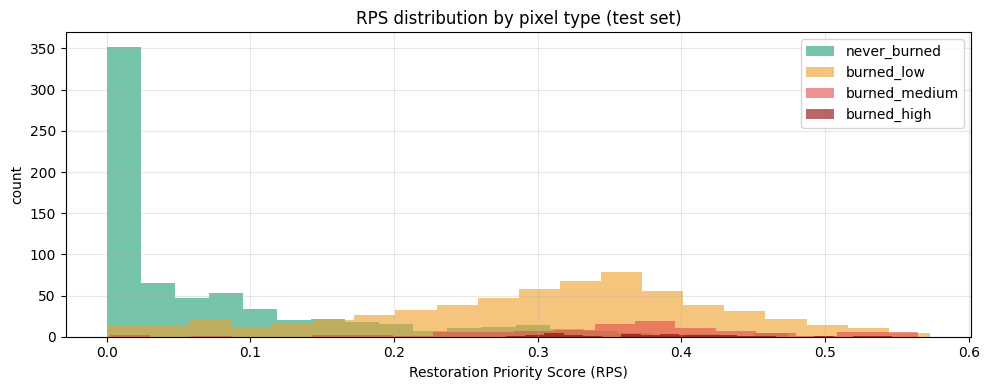


Mean RPS by pixel type:
  never_burned    0.070
  burned_low      0.303
  burned_medium   0.362
  burned_high     0.381


In [15]:
# RPS distribution by pixel type
meta_df = pd.read_csv(
    config.FILES["X_scaled"].replace(".npy", "_meta.csv"))
pixel_types_test = meta_df.iloc[idx_test]["pixel_type"].values

colours = {"never_burned":  "#1D9E75",
           "burned_low":    "#EF9F27",
           "burned_medium": "#E24B4A",
           "burned_high":   "#8B0000"}

fig, ax = plt.subplots(figsize=(10, 4))
for ptype in ["never_burned", "burned_low",
              "burned_medium", "burned_high"]:
    sel = pixel_types_test == ptype
    if sel.any():
        ax.hist(test_rps[sel], bins=20, alpha=0.6,
                label=ptype, color=colours[ptype])
ax.set_xlabel("Restoration Priority Score (RPS)")
ax.set_ylabel("count")
ax.set_title("RPS distribution by pixel type (test set)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{config.PATHS['outputs_fig']}/rps_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nMean RPS by pixel type:")
for ptype in ["never_burned", "burned_low",
              "burned_medium", "burned_high"]:
    sel = pixel_types_test == ptype
    if sel.any():
        print(f"  {ptype:14s}  {test_rps[sel].mean():.3f}")


## 9. Persist model, history, predictions

In [16]:
torch.save(best_state, config.FILES["model_main"])
with open(config.FILES["history_main"], "w") as f:
    json.dump(history, f)
np.savez(
    config.FILES["preds_test"],
    rps=test_rps,
    burned_probs=test_probs,
    burned_labels=test_labels,
    mask=test_mask,
    indices=idx_test,
    threshold=best_thr,
)
print("Saved model, history, and test predictions.")


Saved model, history, and test predictions.


In [17]:
import numpy as np
import pandas as pd

# Load processed data
X       = np.load(config.FILES["X_scaled"])
y       = np.load(config.FILES["y_burned"])
targets = dict(np.load(config.FILES["targets_aux"]))
meta_df = pd.read_csv(
    config.FILES["X_scaled"].replace(".npy", "_meta.csv"))

# Per-class statistics of the *analytical* targets
print("Analytical target statistics by pixel type:")
print("=" * 80)
for ptype in ["never_burned", "burned_low", "burned_medium", "burned_high"]:
    mask = (meta_df["pixel_type"] == ptype).values
    n = mask.sum()
    if n == 0:
        continue
    print(f"\n{ptype}  (n={n})")
    for tname in ["recurrence", "severity", "persistence", "recovery", "rps"]:
        arr = targets[tname][mask]
        print(f"  {tname:12s}  mean={arr.mean():.3f}  "
              f"std={arr.std():.3f}  "
              f"median={np.median(arr):.3f}  "
              f"max={arr.max():.3f}")

# Also check the spread within each category
print("\n\nRPS percentiles by pixel type:")
print("=" * 80)
for ptype in ["never_burned", "burned_low", "burned_medium", "burned_high"]:
    mask = (meta_df["pixel_type"] == ptype).values
    if mask.sum() == 0:
        continue
    rps = targets["rps"][mask]
    print(f"{ptype:14s}  25%={np.percentile(rps,25):.3f}  "
          f"50%={np.percentile(rps,50):.3f}  "
          f"75%={np.percentile(rps,75):.3f}  "
          f"95%={np.percentile(rps,95):.3f}")

Analytical target statistics by pixel type:

never_burned  (n=4500)
  recurrence    mean=0.000  std=0.000  median=0.000  max=0.000
  severity      mean=0.000  std=0.000  median=0.000  max=0.000
  persistence   mean=0.000  std=0.000  median=0.000  max=0.000
  recovery      mean=0.000  std=0.000  median=0.000  max=0.000
  rps           mean=0.000  std=0.000  median=0.000  max=0.000

burned_low  (n=4194)
  recurrence    mean=0.223  std=0.069  median=0.200  max=0.400
  severity      mean=0.180  std=0.233  median=0.128  max=1.000
  persistence   mean=0.383  std=0.200  median=0.352  max=1.000
  recovery      mean=0.348  std=0.306  median=0.300  max=1.000
  rps           mean=0.357  std=0.104  median=0.363  max=0.794

burned_medium  (n=773)
  recurrence    mean=0.626  std=0.071  median=0.600  max=0.800
  severity      mean=0.210  std=0.294  median=0.079  max=1.000
  persistence   mean=0.463  std=0.264  median=0.357  max=0.941
  recovery      mean=0.632  std=0.367  median=0.672  max=1.000
  rp